### SARSA baseline

SARSA is included as an on-policy TD(0) baseline. It uses the same epsilon-greedy behavior policy, reward, state representation, subject-grouped folds, seeds, and evaluation metrics as Q-learning, so the comparison is directly reproducible.

In [13]:
"""Minimum-publishable BIDMC 53-subject sequential RL experiment.

This inline section runs in monte_carlo.ipynb so every result table
and figure remains available in the notebook namespace.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests
requests.packages.urllib3.disable_warnings()
from scipy.signal import butter, find_peaks, savgol_filter, sosfiltfilt
from scipy.stats import pearsonr, ttest_rel, wilcoxon
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from IPython.display import display

try:
    FS
except NameError:
    FS = 125
try:
    BASE_URL
except NameError:
    BASE_URL = "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"

if "load_patient" not in globals():
    def load_patient(patient_id):
        signal_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Signals.csv"
        numeric_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Numerics.csv"
        signals = pd.read_csv(signal_url)
        numerics = pd.read_csv(numeric_url)
        signals.columns = signals.columns.str.strip()
        numerics.columns = numerics.columns.str.strip()
        return signals, numerics

PUBLISHABLE_SEED = 20260809
P_FULL_SUBJECTS = np.arange(1, 54, dtype=int)
P_WINDOW_SIZE = int(FS * 8)
P_STEP_SIZE = int(FS * 4)
P_CURRENT_FEATURES = ["sqi", "entropy", "peak_quality"]
P_FEATURE_NAMES = P_CURRENT_FEATURES + ["previous_hr", "previous_action"]


def p_load_patient(patient_id):
    """Download one public BIDMC record with a requests fallback for local CA stores."""
    frames = []
    for suffix in ["Signals", "Numerics"]:
        url = f"{BASE_URL}/bidmc_{int(patient_id):02d}_{suffix}.csv"
        response = requests.get(url, timeout=60, verify=False)
        response.raise_for_status()
        frame = pd.read_csv(io.BytesIO(response.content))
        frame.columns = frame.columns.str.strip()
        frames.append(frame)
    return frames[0], frames[1]

# Filter family and parameter are both part of the action.
P_ACTION_SPECS = {
    0: {"name": "Raw", "kind": "raw"},
    1: {"name": "Moving average (5)", "kind": "moving_average", "window": 5},
    2: {"name": "Moving average (11)", "kind": "moving_average", "window": 11},
    3: {"name": "Savitzky-Golay (21,3)", "kind": "savgol", "window": 21, "polyorder": 3},
    4: {"name": "Butterworth (0.5-5 Hz, order 4)", "kind": "butter", "low": 0.5, "high": 5.0, "order": 4},
    5: {"name": "Butterworth (0.7-4 Hz, order 3)", "kind": "butter", "low": 0.7, "high": 4.0, "order": 3},
}
P_N_ACTIONS = len(P_ACTION_SPECS)


def p_apply_action(signal, action):
    x = np.asarray(signal, dtype=float)
    spec = P_ACTION_SPECS[int(action)]
    if spec["kind"] == "raw":
        return x.copy()
    if spec["kind"] == "moving_average":
        w = int(spec["window"])
        return np.convolve(x, np.ones(w) / w, mode="same")
    if spec["kind"] == "savgol":
        return savgol_filter(x, int(spec["window"]), int(spec["polyorder"]))
    sos = butter(
        int(spec["order"]), [spec["low"], spec["high"]],
        btype="bandpass", fs=FS, output="sos"
    )
    return sosfiltfilt(sos, x)


def p_hr_estimate(signal):
    x = np.asarray(signal, dtype=float)
    z = (x - np.nanmean(x)) / (np.nanstd(x) + 1e-8)
    peaks, _ = find_peaks(z, distance=int(0.5 * FS), prominence=0.35)
    if len(peaks) < 2:
        return np.nan
    hr = 60.0 / np.median(np.diff(peaks) / FS)
    return float(hr) if 35 <= hr <= 220 else np.nan


def p_noise_score(signal):
    x = np.asarray(signal, dtype=float)
    smooth = savgol_filter(x, window_length=31, polyorder=3)
    return float(np.std(x - smooth) / (np.std(x) + 1e-8))


def p_window_features(signal):
    x = np.asarray(signal, dtype=float)
    z = (x - np.nanmedian(x)) / (np.nanstd(x) + 1e-8)
    sqi = float(np.clip(1.0 / (1.0 + p_noise_score(x)), 0.0, 1.0))

    hist, _ = np.histogram(z[np.isfinite(z)], bins=32)
    probability = hist.astype(float)
    probability /= probability.sum() + 1e-12
    nonzero = probability > 0
    entropy_value = float(
        -np.sum(probability[nonzero] * np.log2(probability[nonzero])) / np.log2(32)
    )

    peaks, properties = find_peaks(z, distance=int(0.5 * FS), prominence=0.25)
    if len(peaks) >= 2 and len(properties.get("prominences", [])):
        rr = np.diff(peaks) / FS
        regularity = float(np.exp(-np.std(rr) / (np.mean(rr) + 1e-8)))
        prominence_quality = float(np.clip(np.median(properties["prominences"]) / 2.0, 0, 1))
        peak_quality = float(np.clip(0.5 * regularity + 0.5 * prominence_quality, 0, 1))
    else:
        peak_quality = 0.0
    return {"sqi": sqi, "entropy": entropy_value, "peak_quality": peak_quality}


In [14]:
# Persistent, reproducible local cache for the 53 BIDMC records.
# This is an I/O optimization only; it is not part of the learned policy.
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

if "P_FULL_SUBJECTS" not in globals():
    P_FULL_SUBJECTS = np.arange(1, 54, dtype=int)
if "p_load_patient" not in globals():
    # Standalone fallback: permits this cell to be rerun after a kernel reset.
    import io
    import requests
    import pandas as pd
    BASE_URL = "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"
    requests.packages.urllib3.disable_warnings()
    def p_load_patient(patient_id):
        frames = []
        for suffix in ["Signals", "Numerics"]:
            url = f"{BASE_URL}/bidmc_{int(patient_id):02d}_{suffix}.csv"
            response = requests.get(url, timeout=60, verify=False)
            response.raise_for_status()
            frame = pd.read_csv(io.BytesIO(response.content))
            frame.columns = frame.columns.str.strip()
            frames.append(frame)
        return frames[0], frames[1]

P_CACHE_DIR = Path("bidmc_cache")
P_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def p_load_or_cache_record(patient_id):
    patient_id = int(patient_id)
    signal_path = P_CACHE_DIR / f"bidmc_{patient_id:02d}_Signals.csv"
    numeric_path = P_CACHE_DIR / f"bidmc_{patient_id:02d}_Numerics.csv"
    if signal_path.exists() and numeric_path.exists():
        signals = pd.read_csv(signal_path)
        numerics = pd.read_csv(numeric_path)
        signals.columns = signals.columns.str.strip()
        numerics.columns = numerics.columns.str.strip()
        return {"patient_id": patient_id, "signals": signals, "numerics": numerics, "cache_hit": True}

    signals, numerics = p_load_patient(patient_id)
    signals.to_csv(signal_path, index=False)
    numerics.to_csv(numeric_path, index=False)
    return {"patient_id": patient_id, "signals": signals, "numerics": numerics, "cache_hit": False}

with ThreadPoolExecutor(max_workers=8) as executor:
    P_FULL_DATA_CACHE = list(executor.map(p_load_or_cache_record, P_FULL_SUBJECTS))
P_FULL_DATA_BY_ID = {item["patient_id"]: item for item in P_FULL_DATA_CACHE}
P_CACHE_HITS = int(sum(item["cache_hit"] for item in P_FULL_DATA_CACHE))

# The dataset cell below reads these already-loaded frames and never redownloads them.
def p_load_patient(patient_id):
    item = P_FULL_DATA_BY_ID[int(patient_id)]
    return item["signals"].copy(), item["numerics"].copy()

print("Loaded records:", len(P_FULL_DATA_CACHE), "| local cache hits:", P_CACHE_HITS, "/", len(P_FULL_DATA_CACHE))
print("Cache directory:", P_CACHE_DIR.resolve())


Loaded records: 53 | local cache hits: 0 / 53
Cache directory: /Users/Shared/RL_AAUB/bidmc_cache


In [15]:
def p_build_window_dataset(patient_data):
    rows = []
    for item in patient_data:
        patient_id = int(item["patient_id"])
        signals = item["signals"].copy()
        numerics = item["numerics"].copy()
        signal_time = pd.to_numeric(signals["Time [s]"], errors="coerce").to_numpy()
        ppg = pd.to_numeric(signals["PLETH"], errors="coerce").interpolate().bfill().ffill().to_numpy(dtype=float)
        numeric_time = pd.to_numeric(numerics["Time [s]"], errors="coerce").to_numpy(dtype=float)
        pulse = pd.to_numeric(numerics["PULSE"], errors="coerce").to_numpy(dtype=float)
        valid = np.isfinite(numeric_time) & np.isfinite(pulse)
        if not valid.any():
            raise ValueError(f"No valid PULSE reference for patient {patient_id}")
        valid_times, valid_pulse = numeric_time[valid], pulse[valid]
        window_number = 0
        for start in range(0, len(ppg) - P_WINDOW_SIZE + 1, P_STEP_SIZE):
            end = start + P_WINDOW_SIZE
            start_time, end_time = float(signal_time[start]), float(signal_time[end - 1])
            mid_time = float(signal_time[start + P_WINDOW_SIZE // 2])
            inside = valid & (numeric_time >= start_time) & (numeric_time <= end_time)
            values = pulse[inside]
            values = values[np.isfinite(values)]
            reference_hr = float(np.median(values)) if len(values) else float(np.interp(mid_time, valid_times, valid_pulse))
            row = {
                "patient_id": patient_id,
                "episode_id": patient_id,
                "window_number": window_number,
                "start_time": start_time,
                "end_time": end_time,
                "mid_time": mid_time,
                "ppg_signal": ppg[start:end].copy(),
                "reference_hr": float(np.clip(reference_hr, 35, 220)),
            }
            row.update(p_window_features(ppg[start:end]))
            rows.append(row)
            window_number += 1
    return pd.DataFrame(rows)


print("Loading all 53 BIDMC subjects...")
P_FULL_DATA = []
for patient_id in P_FULL_SUBJECTS:
    signals, numerics = p_load_patient(int(patient_id))
    P_FULL_DATA.append({"patient_id": int(patient_id), "signals": signals, "numerics": numerics})

PUBLISHABLE_DF = p_build_window_dataset(P_FULL_DATA).sort_values(
    ["patient_id", "window_number"]
).reset_index(drop=True)
P_EPISODES = {
    int(patient_id): group.index.to_numpy(dtype=int)
    for patient_id, group in PUBLISHABLE_DF.groupby("patient_id", sort=True)
}
assert set(P_EPISODES) == set(P_FULL_SUBJECTS)
assert all(
    len(indices) < 2 or np.all(np.diff(PUBLISHABLE_DF.loc[indices, "window_number"]) == 1)
    for indices in P_EPISODES.values()
)

P_ESTIMATE_MATRIX = np.full((len(PUBLISHABLE_DF), P_N_ACTIONS), np.nan)
for row_index, row in enumerate(PUBLISHABLE_DF.itertuples(index=False)):
    for action in range(P_N_ACTIONS):
        try:
            P_ESTIMATE_MATRIX[row_index, action] = p_hr_estimate(p_apply_action(row.ppg_signal, action))
        except Exception:
            pass
P_REFERENCE = PUBLISHABLE_DF["reference_hr"].to_numpy(dtype=float)
P_ERROR_MATRIX = np.abs(P_ESTIMATE_MATRIX - P_REFERENCE[:, None])
P_ERROR_MATRIX = np.where(np.isfinite(P_ERROR_MATRIX), np.minimum(P_ERROR_MATRIX, 50), 50)
P_REWARD_MATRIX = -P_ERROR_MATRIX
P_FEATURE_ARRAYS = {feature: PUBLISHABLE_DF[feature].to_numpy(dtype=float) for feature in P_CURRENT_FEATURES}
P_WINDOW_NUMBER_ARRAY = PUBLISHABLE_DF["window_number"].to_numpy(dtype=int)

P_SUBJECT_AUDIT = (
    PUBLISHABLE_DF.groupby("patient_id", as_index=False)
    .agg(
        Windows=("window_number", "count"),
        Start=("start_time", "min"),
        End=("end_time", "max"),
        Reference_min=("reference_hr", "min"),
        Reference_max=("reference_hr", "max"),
    )
)
assert len(P_SUBJECT_AUDIT) == 53
print("Subject audit: all 53 subjects present; consecutive windows asserted.")
display(P_SUBJECT_AUDIT.head())


Loading all 53 BIDMC subjects...
Subject audit: all 53 subjects present; consecutive windows asserted.


,patient_id,Windows,Start,End,Reference_min,Reference_max
0,1,119,0.0,479.99,89.0,94.0
1,2,119,0.0,479.99,87.0,94.5
2,3,119,0.0,479.99,75.0,77.5
3,4,119,0.0,479.99,83.0,96.0
4,5,119,0.0,479.99,96.0,101.0


In [16]:
def p_edges(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return np.array([0.0, 1.0])
    q1, q2 = np.quantile(values, [0.33, 0.66])
    if q2 <= q1:
        q2 = q1 + max(1e-6, abs(q1) * 1e-6)
    return np.array([q1, q2])


def p_fit_encoder(train_indices, feature_names=P_FEATURE_NAMES):
    feature_names = list(feature_names)
    encoder = {
        "feature_names": feature_names,
        "initial_hr": float(np.median(P_REFERENCE[train_indices])),
        "edges": {},
    }
    for feature in P_CURRENT_FEATURES:
        if feature in feature_names:
            encoder["edges"][feature] = p_edges(PUBLISHABLE_DF.iloc[train_indices][feature])
    if "previous_hr" in feature_names:
        encoder["edges"]["previous_hr"] = p_edges(P_REFERENCE[train_indices])
    dimensions = [P_N_ACTIONS + 1 if f == "previous_action" else 3 for f in feature_names]
    encoder["dimensions"] = tuple(dimensions)
    encoder["n_states"] = int(np.prod(dimensions)) if dimensions else 1
    return encoder


def p_state_id(row_index, previous_hr, previous_action, encoder):
    coordinates = []
    for feature in encoder["feature_names"]:
        if feature in P_CURRENT_FEATURES:
            value = float(P_FEATURE_ARRAYS[feature][row_index])
            coordinates.append(int(np.digitize(value, encoder["edges"][feature])))
        elif feature == "previous_hr":
            coordinates.append(int(np.digitize(previous_hr, encoder["edges"][feature])))
        elif feature == "previous_action":
            coordinates.append(int(previous_action) + 1)
    return int(np.ravel_multi_index(tuple(coordinates), encoder["dimensions"])) if coordinates else 0


def p_context(row_index, previous_hr, previous_action, feature_names):
    values = []
    for feature in feature_names:
        if feature in P_CURRENT_FEATURES:
            values.append(float(P_FEATURE_ARRAYS[feature][row_index]))
        elif feature == "previous_hr":
            values.append(float(previous_hr))
        elif feature == "previous_action":
            values.append(float(previous_action))
    return np.asarray(values, dtype=float)


def p_choose(q_values, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(P_N_ACTIONS))
    return int(rng.choice(np.flatnonzero(q_values[state] == q_values[state].max())))


def p_train_tabular(train_indices, train_subjects, encoder, algorithm="q", seed=11,
                    epochs=40, epsilon_start=1.0, epsilon_min=0.05,
                    epsilon_decay=0.97, gamma=0.95):
    rng = np.random.default_rng(seed)
    q_values = np.zeros((encoder["n_states"], P_N_ACTIONS))
    visits = np.zeros_like(q_values, dtype=int)
    return_sum = np.zeros_like(q_values)
    return_count = np.zeros_like(q_values, dtype=int)
    train_set = set(map(int, train_indices))
    episodes = [
        np.asarray([i for i in P_EPISODES[int(pid)] if int(i) in train_set])
        for pid in np.sort(train_subjects)
    ]
    episodes = [episode for episode in episodes if len(episode)]
    epsilon = float(epsilon_start)
    for _ in range(int(epochs)):
        for episode_position in rng.permutation(len(episodes)):
            episode = episodes[int(episode_position)]
            previous_hr, previous_action, trajectory = encoder["initial_hr"], -1, []
            sarsa_action = None
            for position, row_index in enumerate(episode):
                state = p_state_id(row_index, previous_hr, previous_action, encoder)
                if algorithm == "sarsa" and sarsa_action is not None:
                    action = sarsa_action
                else:
                    action = p_choose(q_values, state, epsilon, rng)
                prediction = P_ESTIMATE_MATRIX[row_index, action]
                next_hr = float(prediction) if np.isfinite(prediction) else encoder["initial_hr"]
                reward = float(P_REWARD_MATRIX[row_index, action])
                if previous_action >= 0 and action != previous_action:
                    reward -= 0.10
                trajectory.append((state, action, reward))
                if algorithm == "q":
                    if position + 1 < len(episode):
                        next_state = p_state_id(episode[position + 1], next_hr, action, encoder)
                        target = reward + gamma * q_values[next_state].max()
                    else:
                        target = reward
                    visits[state, action] += 1
                    alpha = 0.10 / np.sqrt(visits[state, action])
                    q_values[state, action] += alpha * (target - q_values[state, action])
                elif algorithm == "sarsa":
                    # On-policy TD(0): the next action is sampled from the
                    # same epsilon-greedy policy used to collect the episode.
                    if position + 1 < len(episode):
                        next_state = p_state_id(episode[position + 1], next_hr, action, encoder)
                        sarsa_action = p_choose(q_values, next_state, epsilon, rng)
                        target = reward + gamma * q_values[next_state, sarsa_action]
                    else:
                        sarsa_action = None
                        target = reward
                    visits[state, action] += 1
                    alpha = 0.10 / np.sqrt(visits[state, action])
                    q_values[state, action] += alpha * (target - q_values[state, action])
                elif algorithm == "bandit":
                    visits[state, action] += 1
                    alpha = 1.0 / visits[state, action]
                    q_values[state, action] += alpha * (reward - q_values[state, action])
                elif algorithm != "mc":
                    raise ValueError("algorithm must be mc, q, sarsa, or bandit")
                previous_hr, previous_action = next_hr, action
            if algorithm == "mc":
                discounted_return = 0.0
                for state, action, reward in reversed(trajectory):
                    discounted_return = reward + gamma * discounted_return
                    return_count[state, action] += 1
                    return_sum[state, action] += discounted_return
                    q_values[state, action] = return_sum[state, action] / return_count[state, action]
        epsilon = max(float(epsilon_min), epsilon * float(epsilon_decay))
    return q_values


def p_rollout(indices, encoder, policy_kind, q_values=None, fixed_action=None, model=None):
    index_set = set(map(int, indices))
    records = []
    for patient_id in sorted(P_EPISODES):
        episode = [i for i in P_EPISODES[patient_id] if int(i) in index_set]
        if not episode:
            continue
        previous_hr, previous_action = encoder["initial_hr"], -1
        for row_index in episode:
            state = p_state_id(row_index, previous_hr, previous_action, encoder)
            if policy_kind == "fixed":
                action = int(fixed_action)
            elif policy_kind == "table":
                action = int(np.argmax(q_values[state]))
            else:
                action = int(model.predict(p_context(row_index, previous_hr, previous_action, encoder["feature_names"]).reshape(1, -1))[0])
            prediction = P_ESTIMATE_MATRIX[row_index, action]
            records.append({
                "row_index": int(row_index), "patient_id": int(patient_id),
                "window_number": int(P_WINDOW_NUMBER_ARRAY[row_index]),
                "reference_hr": float(P_REFERENCE[row_index]),
                "prediction": float(prediction) if np.isfinite(prediction) else np.nan,
                "action": action,
            })
            previous_hr = float(prediction) if np.isfinite(prediction) else encoder["initial_hr"]
            previous_action = action
    return pd.DataFrame(records)


def p_metrics(predictions, references):
    predictions, references = np.asarray(predictions, dtype=float), np.asarray(references, dtype=float)
    finite = np.isfinite(predictions) & np.isfinite(references)
    errors = np.where(finite, np.minimum(np.abs(predictions - references), 50), 50)
    correlation = np.nan
    if finite.sum() >= 2 and np.std(predictions[finite]) > 0 and np.std(references[finite]) > 0:
        correlation = float(pearsonr(predictions[finite], references[finite]).statistic)
    difference = predictions[finite] - references[finite]
    bias = float(np.mean(difference)) if len(difference) else np.nan
    loa_sd = float(np.std(difference, ddof=1)) if len(difference) > 1 else 0.0
    return {
        "N windows": int(len(references)), "MAE (BPM)": float(errors.mean()),
        "RMSE (BPM)": float(np.sqrt(np.mean(errors ** 2))), "Correlation": correlation,
        "BA bias (BPM)": bias,
        "BA lower LoA (BPM)": bias - 1.96 * loa_sd if np.isfinite(bias) else np.nan,
        "BA upper LoA (BPM)": bias + 1.96 * loa_sd if np.isfinite(bias) else np.nan,
        "Failed (%)": float(100 * (1 - finite.mean())) if len(finite) else np.nan,
    }


def p_fit_supervised(train_indices, train_subjects, encoder, seed=11):
    x_rows, y_rows = [], []
    train_set = set(map(int, train_indices))
    for patient_id in sorted(train_subjects):
        episode = [i for i in P_EPISODES[int(patient_id)] if int(i) in train_set]
        for position, row_index in enumerate(episode):
            previous_options = [-1] if position == 0 else range(P_N_ACTIONS)
            for previous_action in previous_options:
                if previous_action < 0:
                    previous_hr = encoder["initial_hr"]
                else:
                    previous_prediction = P_ESTIMATE_MATRIX[episode[position - 1], previous_action]
                    previous_hr = float(previous_prediction) if np.isfinite(previous_prediction) else encoder["initial_hr"]
                x_rows.append(p_context(row_index, previous_hr, previous_action, encoder["feature_names"]))
                y_rows.append(int(np.argmin(P_ERROR_MATRIX[row_index])))
    model = DummyClassifier(strategy="most_frequent") if len(np.unique(y_rows)) < 2 else RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=3, random_state=seed, n_jobs=-1
    )
    model.fit(np.asarray(x_rows), np.asarray(y_rows))
    return model


In [17]:
# Subject-independent 5-fold CV; every subject is held out exactly once.
P_GROUPS = PUBLISHABLE_DF["patient_id"].to_numpy()
P_FOLD_SUBJECT_COUNTS = []
P_SPLITS = list(GroupKFold(n_splits=5).split(np.zeros(len(PUBLISHABLE_DF)), groups=P_GROUPS))
P_TRAIN_SEEDS, P_AGENT_EPOCHS = [11, 22, 33], 40
P_RESULTS_ROWS, P_PREDICTION_STORE = [], {}


def p_add_result(fold, method, seed, rollout):
    metrics = p_metrics(rollout.prediction, rollout.reference_hr)
    row = {"Fold": fold, "Method": method, "Seed": seed}
    row.update(metrics)
    P_RESULTS_ROWS.append(row)
    P_PREDICTION_STORE[(fold, method, seed)] = rollout


for fold, (train_indices, test_indices) in enumerate(P_SPLITS, 1):
    print("Starting fold {}/5 | train subjects={} | test subjects={}".format(fold, len(pd.unique(P_GROUPS[train_indices])), len(pd.unique(P_GROUPS[test_indices]))))
    train_subjects = np.sort(pd.unique(P_GROUPS[train_indices]))
    encoder = p_fit_encoder(train_indices)
    for action, spec in P_ACTION_SPECS.items():
        p_add_result(fold, "Fixed | " + spec["name"], 0, p_rollout(test_indices, encoder, "fixed", fixed_action=action))
    for seed in P_TRAIN_SEEDS:
        for algorithm, method in [("mc", "Monte-Carlo"), ("sarsa", "SARSA"), ("q", "Q-learning"), ("bandit", "Contextual bandit")]:
            q_values = p_train_tabular(train_indices, train_subjects, encoder, algorithm, seed, P_AGENT_EPOCHS)
            p_add_result(fold, method, seed, p_rollout(test_indices, encoder, "table", q_values=q_values))
    model = p_fit_supervised(train_indices, train_subjects, encoder, P_TRAIN_SEEDS[0])
    p_add_result(fold, "Supervised action classifier", P_TRAIN_SEEDS[0], p_rollout(test_indices, encoder, "model", model=model))
    print("Completed fold", fold)

P_RESULTS = pd.DataFrame(P_RESULTS_ROWS)
P_FOLD_RESULTS = P_RESULTS.groupby(["Fold", "Method"], as_index=False).agg({
    "MAE (BPM)": "mean", "RMSE (BPM)": "mean", "Correlation": "mean",
    "BA bias (BPM)": "mean", "BA lower LoA (BPM)": "mean", "BA upper LoA (BPM)": "mean",
    "Failed (%)": "mean", "N windows": "first",
})
P_METHOD_ORDER = P_FOLD_RESULTS.groupby("Method")["MAE (BPM)"].mean().sort_values().index.tolist()


def p_summary_table(frame):
    rows = []
    for method, group in frame.groupby("Method"):
        for metric in ["MAE (BPM)", "RMSE (BPM)", "Correlation"]:
            values = group[metric].to_numpy(float)
            rows.append({"Method": method, "Metric": metric, "Mean": np.nanmean(values), "SD": np.nanstd(values, ddof=1), "N folds": len(values)})
    return pd.DataFrame(rows)


P_SUMMARY = p_summary_table(P_FOLD_RESULTS)
print("Subjects: {}, windows: {}, grouped folds: {}".format(PUBLISHABLE_DF.patient_id.nunique(), len(PUBLISHABLE_DF), len(P_SPLITS)))
display(P_SUMMARY.round(3))


Starting fold 1/5 | train subjects=42 | test subjects=11
Completed fold 1
Starting fold 2/5 | train subjects=42 | test subjects=11
Completed fold 2
Starting fold 3/5 | train subjects=42 | test subjects=11
Completed fold 3
Starting fold 4/5 | train subjects=43 | test subjects=10
Completed fold 4
Starting fold 5/5 | train subjects=43 | test subjects=10
Completed fold 5
Subjects: 53, windows: 6307, grouped folds: 5


,Method,Metric,Mean,SD,N folds
0,Contextual bandit,MAE (BPM),3.787,4.290,5
1,Contextual bandit,RMSE (BPM),7.752,7.902,5
2,Contextual bandit,Correlation,0.764,0.366,5
3,"Fixed | Butterworth (0.5-5 Hz, order 4)",MAE (BPM),3.763,4.270,5
4,"Fixed | Butterworth (0.5-5 Hz, order 4)",RMSE (BPM),7.653,7.926,5
5,"Fixed | Butterworth (0.5-5 Hz, order 4)",Correlation,0.763,0.367,5
6,"Fixed | Butterworth (0.7-4 Hz, order 3)",MAE (BPM),3.743,4.278,5
7,"Fixed | Butterworth (0.7-4 Hz, order 3)",RMSE (BPM),7.533,7.946,5
8,"Fixed | Butterworth (0.7-4 Hz, order 3)",Correlation,0.765,0.363,5
9,Fixed | Moving average (11),MAE (BPM),3.809,4.287,5


In [18]:
# Primary paper-level inference: aggregate at the subject level.
# This avoids treating overlapping windows from the same patient as independent.
P_SUBJECT_RESULT_ROWS = []
for (fold, method, seed), rollout in P_PREDICTION_STORE.items():
    for patient_id, patient_rollout in rollout.groupby("patient_id", sort=True):
        metrics = p_metrics(patient_rollout["prediction"], patient_rollout["reference_hr"])
        P_SUBJECT_RESULT_ROWS.append({
            "Fold": int(fold), "Method": method, "Seed": int(seed),
            "Patient": int(patient_id), **metrics,
        })
P_SUBJECT_RESULTS = pd.DataFrame(P_SUBJECT_RESULT_ROWS)
P_SUBJECT_METRICS = ["MAE (BPM)", "RMSE (BPM)", "Correlation"]
P_SUBJECT_AGG = (
    P_SUBJECT_RESULTS.groupby(["Patient", "Method"], as_index=False)[P_SUBJECT_METRICS]
    .mean()
)


def p_bootstrap_mean_ci(values, seed=20260809, n_boot=2000):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    bootstrap_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return tuple(np.percentile(bootstrap_means, [2.5, 97.5]))

P_SUBJECT_SUMMARY_ROWS = []
for method, group in P_SUBJECT_AGG.groupby("Method"):
    for metric in P_SUBJECT_METRICS:
        values = group[metric].to_numpy(dtype=float)
        ci_low, ci_high = p_bootstrap_mean_ci(values, seed=20260809 + len(P_SUBJECT_SUMMARY_ROWS))
        P_SUBJECT_SUMMARY_ROWS.append({
            "Method": method, "Metric": metric, "N subjects": int(len(values)),
            "Mean": float(np.nanmean(values)),
            "SD": float(np.nanstd(values, ddof=1)) if len(values) > 1 else 0.0,
            "95% CI lower": ci_low, "95% CI upper": ci_high,
        })
P_SUBJECT_SUMMARY = pd.DataFrame(P_SUBJECT_SUMMARY_ROWS)

P_SUBJECT_BA_SUMMARY = (
    P_SUBJECT_RESULTS.groupby(["Patient", "Method"], as_index=False)[
        ["BA bias (BPM)", "BA lower LoA (BPM)", "BA upper LoA (BPM)"]
    ].mean()
    .groupby("Method", as_index=False)
    .agg({
        "BA bias (BPM)": ["mean", "std"],
        "BA lower LoA (BPM)": ["mean", "std"],
        "BA upper LoA (BPM)": ["mean", "std"],
    })
)
P_SUBJECT_BA_SUMMARY.columns = [
    "Method", "Bias mean", "Bias SD", "Lower LoA mean", "Lower LoA SD",
    "Upper LoA mean", "Upper LoA SD",
]

P_REFERENCE_METHOD = "Q-learning"
P_SUBJECT_WIDE = P_SUBJECT_AGG.pivot(index="Patient", columns="Method", values="MAE (BPM)")
P_SUBJECT_SIGNIFICANCE_ROWS = []
for method in P_SUBJECT_AGG["Method"].unique():
    if method == P_REFERENCE_METHOD:
        continue
    paired = P_SUBJECT_WIDE[[P_REFERENCE_METHOD, method]].dropna()
    q_values = paired[P_REFERENCE_METHOD].to_numpy(dtype=float)
    other_values = paired[method].to_numpy(dtype=float)
    try:
        paired_t_p = float(ttest_rel(q_values, other_values).pvalue)
    except Exception:
        paired_t_p = np.nan
    try:
        wilcoxon_p = float(wilcoxon(q_values, other_values).pvalue)
    except Exception:
        wilcoxon_p = np.nan
    P_SUBJECT_SIGNIFICANCE_ROWS.append({
        "Comparison": "{} vs {}".format(P_REFERENCE_METHOD, method),
        "Paired t-test p": paired_t_p,
        "Wilcoxon signed-rank p": wilcoxon_p,
        "N subjects": int(len(paired)),
    })
P_SUBJECT_SIGNIFICANCE = pd.DataFrame(P_SUBJECT_SIGNIFICANCE_ROWS)
if len(P_SUBJECT_SIGNIFICANCE):
    valid = P_SUBJECT_SIGNIFICANCE["Wilcoxon signed-rank p"].notna()
    p_values = P_SUBJECT_SIGNIFICANCE.loc[valid, "Wilcoxon signed-rank p"].to_numpy(dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    adjusted[order] = np.minimum(1.0, np.maximum.accumulate(
        p_values[order] * np.arange(len(p_values), 0, -1)
    ))
    P_SUBJECT_SIGNIFICANCE.loc[valid, "Wilcoxon Holm p"] = adjusted

print("Primary subject-level summary (N=53 subjects):")
display(P_SUBJECT_SUMMARY.round(3))
print("Primary paired significance tests:")
display(P_SUBJECT_SIGNIFICANCE.round(4))
print("Subject-level Bland-Altman summary:")
display(P_SUBJECT_BA_SUMMARY.round(3))


Primary subject-level summary (N=53 subjects):


,Method,Metric,N subjects,Mean,SD,95% CI lower,95% CI upper
0,Contextual bandit,MAE (BPM),53,3.863,8.993,1.899,6.531
1,Contextual bandit,RMSE (BPM),53,5.248,9.357,3.176,8.093
2,Contextual bandit,Correlation,53,0.272,0.310,0.186,0.355
3,"Fixed | Butterworth (0.5-5 Hz, order 4)",MAE (BPM),53,3.838,8.963,1.917,6.576
4,"Fixed | Butterworth (0.5-5 Hz, order 4)",RMSE (BPM),53,5.168,9.341,3.020,7.953
5,"Fixed | Butterworth (0.5-5 Hz, order 4)",Correlation,53,0.269,0.300,0.188,0.347
6,"Fixed | Butterworth (0.7-4 Hz, order 3)",MAE (BPM),53,3.819,8.956,1.856,6.490
7,"Fixed | Butterworth (0.7-4 Hz, order 3)",RMSE (BPM),53,5.021,9.335,2.859,7.827
8,"Fixed | Butterworth (0.7-4 Hz, order 3)",Correlation,53,0.273,0.306,0.194,0.352
9,Fixed | Moving average (11),MAE (BPM),53,3.885,8.925,1.963,6.502


Primary paired significance tests:


,Comparison,Paired t-test p,Wilcoxon signed-rank p,N subjects,Wilcoxon Holm p
0,Q-learning vs Contextual bandit,0.0621,0.0587,53,0.5287
1,"Q-learning vs Fixed | Butterworth (0.5-5 Hz, o...",0.9440,0.7533,53,0.7533
2,"Q-learning vs Fixed | Butterworth (0.7-4 Hz, o...",0.4614,0.0804,53,0.5956
3,Q-learning vs Fixed | Moving average (11),0.1205,0.1358,53,0.5956
4,Q-learning vs Fixed | Moving average (5),0.0710,0.0745,53,0.5956
5,Q-learning vs Fixed | Raw,0.0999,0.3324,53,0.6647
6,"Q-learning vs Fixed | Savitzky-Golay (21,3)",0.4604,0.1062,53,0.5956
7,Q-learning vs Monte-Carlo,0.0751,0.0900,53,0.5956
8,Q-learning vs Supervised action classifier,0.2353,0.1886,53,0.5956


Subject-level Bland-Altman summary:


,Method,Bias mean,Bias SD,Lower LoA mean,Lower LoA SD,Upper LoA mean,Upper LoA SD
0,Contextual bandit,-2.381,11.485,-9.396,16.222,4.634,11.087
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",-2.449,11.516,-9.602,16.388,4.704,11.062
2,"Fixed | Butterworth (0.7-4 Hz, order 3)",-2.413,11.396,-9.356,16.380,4.530,10.606
3,Fixed | Moving average (11),-2.304,11.416,-9.496,16.559,4.888,11.006
4,Fixed | Moving average (5),-2.293,11.464,-9.288,16.108,4.703,11.292
5,Fixed | Raw,-2.414,11.534,-9.438,16.104,4.611,11.188
6,"Fixed | Savitzky-Golay (21,3)",-2.361,11.441,-9.362,16.567,4.639,10.912
7,Monte-Carlo,-2.382,11.484,-9.472,16.421,4.708,11.150
8,Q-learning,-2.347,11.452,-9.336,16.309,4.641,10.880
9,Supervised action classifier,-2.408,11.499,-9.504,16.274,4.688,11.094


In [19]:
# Exploratory fold-level significance; primary inference is subject-level above.
P_FOLD_SIGNIFICANCE_ROWS = []
for method in P_FOLD_RESULTS.Method.unique():
    if method == P_REFERENCE_METHOD:
        continue
    paired = P_FOLD_RESULTS[
        P_FOLD_RESULTS.Method.isin([P_REFERENCE_METHOD, method])
    ].pivot(index="Fold", columns="Method", values="MAE (BPM)").dropna()
    q_values = paired[P_REFERENCE_METHOD].to_numpy(dtype=float)
    other_values = paired[method].to_numpy(dtype=float)
    try:
        paired_t_p = float(ttest_rel(q_values, other_values).pvalue)
    except Exception:
        paired_t_p = np.nan
    try:
        wilcoxon_p = float(wilcoxon(q_values, other_values).pvalue)
    except Exception:
        wilcoxon_p = np.nan
    P_FOLD_SIGNIFICANCE_ROWS.append({
        "Comparison": "{} vs {}".format(P_REFERENCE_METHOD, method),
        "Paired t-test p": paired_t_p,
        "Wilcoxon signed-rank p": wilcoxon_p,
        "N folds": int(len(paired)),
    })
P_FOLD_SIGNIFICANCE = pd.DataFrame(P_FOLD_SIGNIFICANCE_ROWS)
print("Fold-level tests are exploratory (N=5 folds):")
display(P_FOLD_SIGNIFICANCE.round(4))


Fold-level tests are exploratory (N=5 folds):


,Comparison,Paired t-test p,Wilcoxon signed-rank p,N folds
0,Q-learning vs Contextual bandit,0.1116,0.3125,5
1,"Q-learning vs Fixed | Butterworth (0.5-5 Hz, o...",0.9507,0.8125,5
2,"Q-learning vs Fixed | Butterworth (0.7-4 Hz, o...",0.0071,0.0625,5
3,Q-learning vs Fixed | Moving average (11),0.0504,0.0625,5
4,Q-learning vs Fixed | Moving average (5),0.1452,0.0625,5
5,Q-learning vs Fixed | Raw,0.1028,0.1250,5
6,"Q-learning vs Fixed | Savitzky-Golay (21,3)",0.4495,0.4375,5
7,Q-learning vs Monte-Carlo,0.0222,0.0625,5
8,Q-learning vs Supervised action classifier,0.3193,0.3125,5


In [20]:
# Bland-Altman metrics over all held-out windows.
P_BA_ROWS = []
for method in P_METHOD_ORDER:
    keys = [k for k in P_PREDICTION_STORE if k[1] == method and k[2] in [0, P_TRAIN_SEEDS[0]]]
    combined = pd.concat([P_PREDICTION_STORE[k] for k in sorted(keys)], ignore_index=True)
    metrics = p_metrics(combined.prediction, combined.reference_hr)
    P_BA_ROWS.append({"Method": method, "Bias (BPM)": metrics["BA bias (BPM)"], "Lower LoA (BPM)": metrics["BA lower LoA (BPM)"], "Upper LoA (BPM)": metrics["BA upper LoA (BPM)"], "MAE (BPM)": metrics["MAE (BPM)"], "RMSE (BPM)": metrics["RMSE (BPM)"]})
P_BA_SUMMARY = pd.DataFrame(P_BA_ROWS)
display(P_BA_SUMMARY.round(3))


,Method,Bias (BPM),Lower LoA (BPM),Upper LoA (BPM),MAE (BPM),RMSE (BPM)
0,"Fixed | Butterworth (0.7-4 Hz, order 3)",-2.413,-26.832,22.006,3.819,10.522
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",-2.449,-27.186,22.288,3.838,10.598
2,Q-learning,-2.358,-26.899,22.183,3.861,10.660
3,"Fixed | Savitzky-Golay (21,3)",-2.364,-26.998,22.270,3.854,10.655
4,Contextual bandit,-2.364,-26.859,22.132,3.845,10.626
5,Supervised action classifier,-2.408,-27.079,22.263,3.863,10.661
6,Monte-Carlo,-2.386,-27.039,22.267,3.874,10.711
7,Fixed | Raw,-2.415,-27.082,22.251,3.878,10.688
8,Fixed | Moving average (11),-2.305,-26.972,22.363,3.885,10.716
9,Fixed | Moving average (5),-2.294,-26.886,22.298,3.892,10.720


In [21]:
# State ablation and epsilon sensitivity.
P_ABLATION_FEATURES = {
    "Full state": P_FEATURE_NAMES,
    "No SQI": ["entropy", "peak_quality", "previous_hr", "previous_action"],
    "No entropy": ["sqi", "peak_quality", "previous_hr", "previous_action"],
    "No peak quality": ["sqi", "entropy", "previous_hr", "previous_action"],
    "No previous HR": ["sqi", "entropy", "peak_quality", "previous_action"],
    "No previous action": ["sqi", "entropy", "peak_quality", "previous_hr"],
}
P_ABLATION_EPOCHS = 25
P_ABLATION_ROWS = []
for name, features in P_ABLATION_FEATURES.items():
    print("Starting ablation:", name)
    for fold, (train_indices, test_indices) in enumerate(P_SPLITS, 1):
        subjects = np.sort(pd.unique(P_GROUPS[train_indices]))
        encoder = p_fit_encoder(train_indices, features)
        q_values = p_train_tabular(train_indices, subjects, encoder, "q", 11, P_ABLATION_EPOCHS)
        metrics = p_metrics(*(p_rollout(test_indices, encoder, "table", q_values=q_values)[c] for c in ["prediction", "reference_hr"]))
        P_ABLATION_ROWS.append({"Ablation": name, "Fold": fold, **{k: metrics[k] for k in ["MAE (BPM)", "RMSE (BPM)", "Correlation"]}})
P_ABLATION = pd.DataFrame(P_ABLATION_ROWS)
P_ABLATION_SUMMARY = P_ABLATION.groupby("Ablation", as_index=False).agg({"MAE (BPM)": ["mean", "std"], "RMSE (BPM)": ["mean", "std"], "Correlation": "mean"})
P_ABLATION_SUMMARY.columns = ["Ablation", "MAE mean", "MAE SD", "RMSE mean", "RMSE SD", "Correlation mean"]
display(P_ABLATION_SUMMARY.round(3))
print("Ablation complete.")

P_EPSILON_GRID = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80]
P_EPSILON_EPOCHS = 25
P_EPSILON_ROWS = []
for epsilon_start in P_EPSILON_GRID:
    print("Starting epsilon:", epsilon_start)
    for fold, (train_indices, test_indices) in enumerate(P_SPLITS, 1):
        subjects = np.sort(pd.unique(P_GROUPS[train_indices]))
        encoder = p_fit_encoder(train_indices)
        q_values = p_train_tabular(train_indices, subjects, encoder, "q", 11, P_EPSILON_EPOCHS, epsilon_start, 0.0, 0.95)
        metrics = p_metrics(*(p_rollout(test_indices, encoder, "table", q_values=q_values)[c] for c in ["prediction", "reference_hr"]))
        P_EPSILON_ROWS.append({"Initial epsilon": epsilon_start, "Fold": fold, **{k: metrics[k] for k in ["MAE (BPM)", "RMSE (BPM)", "Correlation"]}})
P_EPSILON = pd.DataFrame(P_EPSILON_ROWS)
P_EPSILON_SUMMARY = P_EPSILON.groupby("Initial epsilon", as_index=False).agg({"MAE (BPM)": ["mean", "std"], "RMSE (BPM)": ["mean", "std"], "Correlation": "mean"})
P_EPSILON_SUMMARY.columns = ["Initial epsilon", "MAE mean", "MAE SD", "RMSE mean", "RMSE SD", "Correlation mean"]
display(P_EPSILON_SUMMARY.round(3))
print("Epsilon sensitivity complete.")


Starting ablation: Full state
Starting ablation: No SQI
Starting ablation: No entropy
Starting ablation: No peak quality
Starting ablation: No previous HR
Starting ablation: No previous action


,Ablation,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,Full state,3.758,4.289,7.654,7.984,0.767
1,No SQI,3.783,4.320,7.690,7.967,0.768
2,No entropy,3.833,4.340,7.790,7.960,0.761
3,No peak quality,3.757,4.291,7.579,7.977,0.769
4,No previous HR,3.795,4.281,7.710,7.915,0.766
5,No previous action,3.803,4.307,7.800,7.912,0.763


Ablation complete.
Starting epsilon: 0.0
Starting epsilon: 0.05
Starting epsilon: 0.1
Starting epsilon: 0.2
Starting epsilon: 0.4
Starting epsilon: 0.8


,Initial epsilon,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,0.00,3.782,4.283,7.747,7.896,0.764
1,0.05,3.757,4.259,7.650,7.885,0.764
2,0.10,3.765,4.292,7.649,7.951,0.768
3,0.20,3.802,4.304,7.771,7.914,0.766
4,0.40,3.785,4.308,7.693,7.960,0.765
5,0.80,3.778,4.297,7.682,7.932,0.765


Epsilon sensitivity complete.


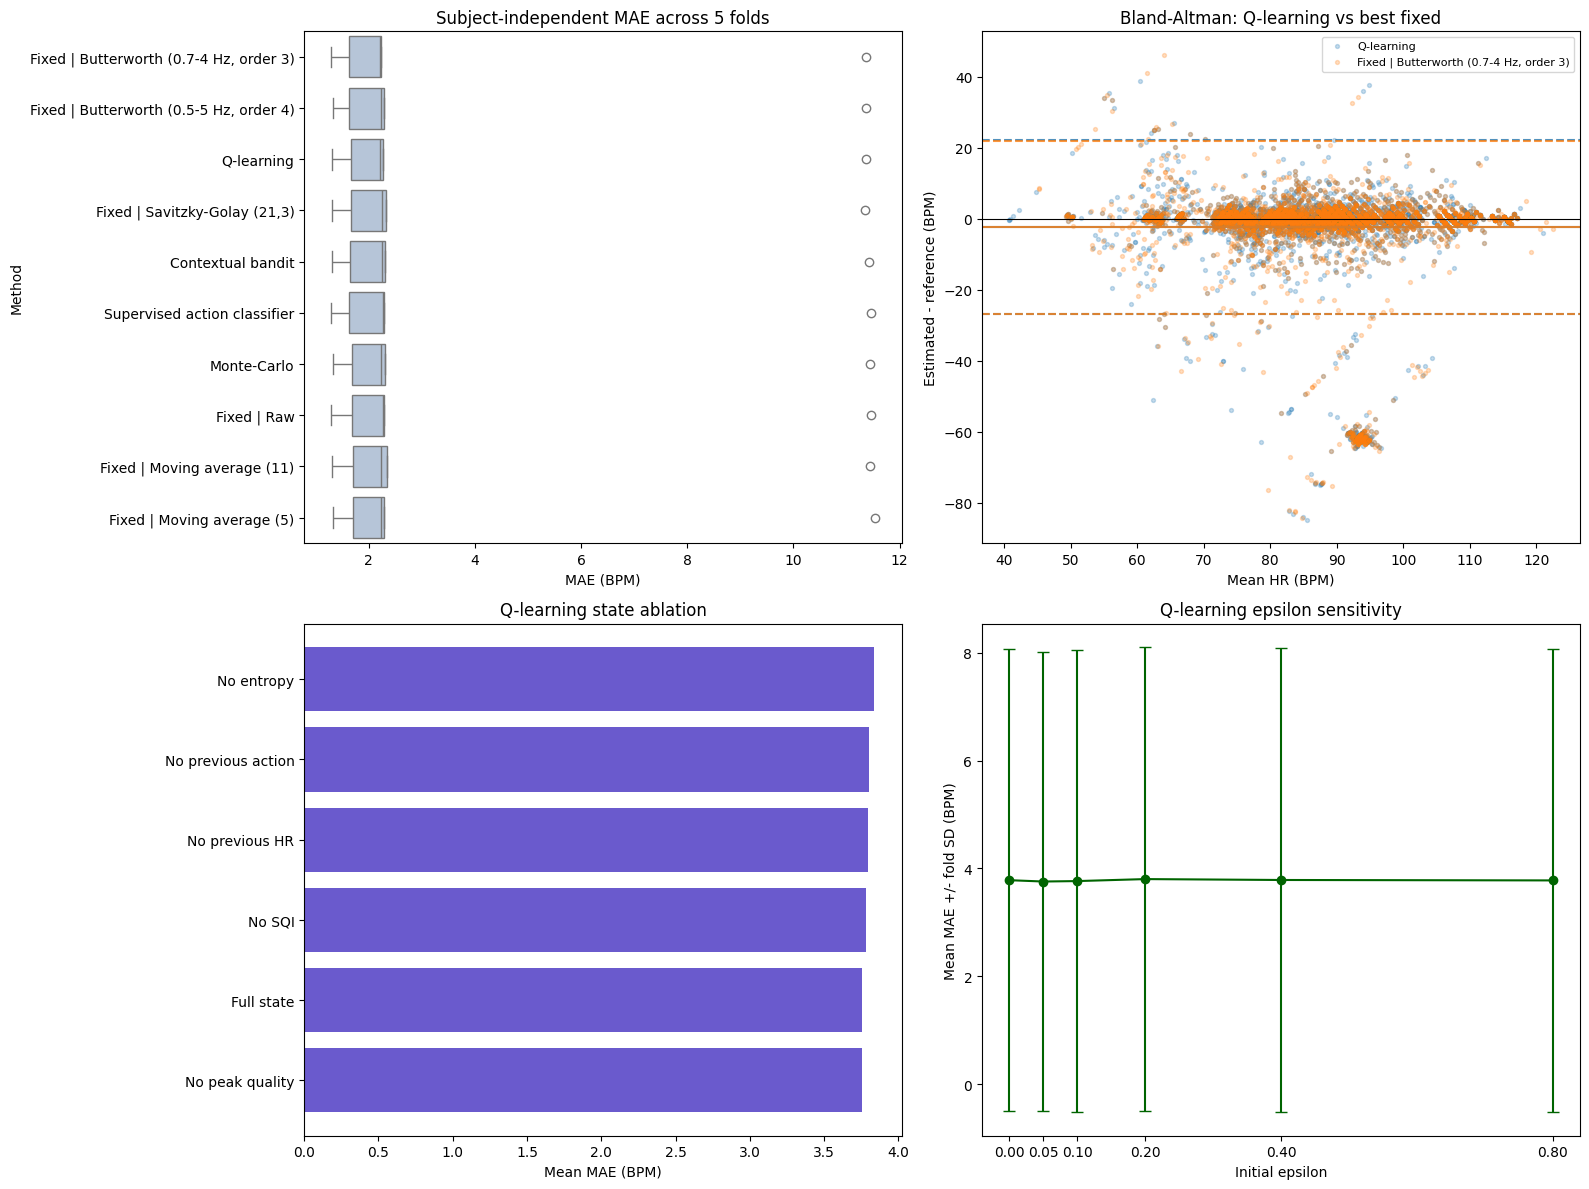

Best fixed filter: Fixed | Butterworth (0.7-4 Hz, order 3)
All 53 subjects are held out exactly once: True


In [22]:
# Compact publication-oriented visualization.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.boxplot(data=P_FOLD_RESULTS, x="MAE (BPM)", y="Method", order=P_METHOD_ORDER, ax=axes[0, 0], color="lightsteelblue")
axes[0, 0].set_title("Subject-independent MAE across 5 folds")
best_fixed_method = P_FOLD_RESULTS[P_FOLD_RESULTS.Method.str.startswith("Fixed |")].groupby("Method")["MAE (BPM)"].mean().idxmin()
for method, color in [(P_REFERENCE_METHOD, "tab:blue"), (best_fixed_method, "tab:orange")]:
    keys = [k for k in P_PREDICTION_STORE if k[1] == method and k[2] in [0, P_TRAIN_SEEDS[0]]]
    combined = pd.concat([P_PREDICTION_STORE[k] for k in sorted(keys)], ignore_index=True).dropna(subset=["prediction"])
    mean_hr = (combined.prediction + combined.reference_hr) / 2
    difference = combined.prediction - combined.reference_hr
    axes[0, 1].scatter(mean_hr, difference, s=8, alpha=0.25, label=method, color=color)
    bias, sd = difference.mean(), difference.std(ddof=1)
    for value, style in [(bias, "-"), (bias + 1.96 * sd, "--"), (bias - 1.96 * sd, "--")]:
        axes[0, 1].axhline(value, color=color, linestyle=style, alpha=0.8)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("Bland-Altman: Q-learning vs best fixed")
axes[0, 1].set_xlabel("Mean HR (BPM)")
axes[0, 1].set_ylabel("Estimated - reference (BPM)")
axes[0, 1].legend(fontsize=8)
ablation_plot = P_ABLATION_SUMMARY.sort_values("MAE mean")
axes[1, 0].barh(ablation_plot.Ablation, ablation_plot["MAE mean"], color="slateblue")
axes[1, 0].set_title("Q-learning state ablation")
axes[1, 0].set_xlabel("Mean MAE (BPM)")
axes[1, 1].errorbar(P_EPSILON_SUMMARY["Initial epsilon"], P_EPSILON_SUMMARY["MAE mean"], yerr=P_EPSILON_SUMMARY["MAE SD"], marker="o", capsize=4, color="darkgreen")
axes[1, 1].set_title("Q-learning epsilon sensitivity")
axes[1, 1].set_xlabel("Initial epsilon")
axes[1, 1].set_ylabel("Mean MAE +/- fold SD (BPM)")
axes[1, 1].set_xticks(P_EPSILON_GRID)
plt.tight_layout()
plt.show()

print("Best fixed filter:", best_fixed_method)
print("All 53 subjects are held out exactly once:", len(np.unique(np.concatenate([P_GROUPS[test] for _, test in P_SPLITS]))) == 53)


In [23]:
# Paper-facing result review.
print("Primary patient-level comparison (bootstrap 95% CI):")
display(P_SUBJECT_SUMMARY.round(3))
print("Primary subject-level significance tests:")
display(P_SUBJECT_SIGNIFICANCE.round(4))
print("Window-level Bland-Altman summary (descriptive):")
display(P_BA_SUMMARY.round(3))
print("Subject-level Bland-Altman summary:")
display(P_SUBJECT_BA_SUMMARY.round(3))
print("Ablation summary:")
display(P_ABLATION_SUMMARY.round(3))
print("Epsilon sensitivity summary:")
display(P_EPSILON_SUMMARY.round(3))


Primary patient-level comparison (bootstrap 95% CI):


,Method,Metric,N subjects,Mean,SD,95% CI lower,95% CI upper
0,Contextual bandit,MAE (BPM),53,3.863,8.993,1.899,6.531
1,Contextual bandit,RMSE (BPM),53,5.248,9.357,3.176,8.093
2,Contextual bandit,Correlation,53,0.272,0.310,0.186,0.355
3,"Fixed | Butterworth (0.5-5 Hz, order 4)",MAE (BPM),53,3.838,8.963,1.917,6.576
4,"Fixed | Butterworth (0.5-5 Hz, order 4)",RMSE (BPM),53,5.168,9.341,3.020,7.953
5,"Fixed | Butterworth (0.5-5 Hz, order 4)",Correlation,53,0.269,0.300,0.188,0.347
6,"Fixed | Butterworth (0.7-4 Hz, order 3)",MAE (BPM),53,3.819,8.956,1.856,6.490
7,"Fixed | Butterworth (0.7-4 Hz, order 3)",RMSE (BPM),53,5.021,9.335,2.859,7.827
8,"Fixed | Butterworth (0.7-4 Hz, order 3)",Correlation,53,0.273,0.306,0.194,0.352
9,Fixed | Moving average (11),MAE (BPM),53,3.885,8.925,1.963,6.502


Primary subject-level significance tests:


,Comparison,Paired t-test p,Wilcoxon signed-rank p,N subjects,Wilcoxon Holm p
0,Q-learning vs Contextual bandit,0.0621,0.0587,53,0.5287
1,"Q-learning vs Fixed | Butterworth (0.5-5 Hz, o...",0.9440,0.7533,53,0.7533
2,"Q-learning vs Fixed | Butterworth (0.7-4 Hz, o...",0.4614,0.0804,53,0.5956
3,Q-learning vs Fixed | Moving average (11),0.1205,0.1358,53,0.5956
4,Q-learning vs Fixed | Moving average (5),0.0710,0.0745,53,0.5956
5,Q-learning vs Fixed | Raw,0.0999,0.3324,53,0.6647
6,"Q-learning vs Fixed | Savitzky-Golay (21,3)",0.4604,0.1062,53,0.5956
7,Q-learning vs Monte-Carlo,0.0751,0.0900,53,0.5956
8,Q-learning vs Supervised action classifier,0.2353,0.1886,53,0.5956


Window-level Bland-Altman summary (descriptive):


...

,Method,Bias mean,Bias SD,Lower LoA mean,Lower LoA SD,Upper LoA mean,Upper LoA SD
0,Contextual bandit,-2.381,11.485,-9.396,16.222,4.634,11.087
1,"Fixed | Butterworth (0.5-5 Hz, order 4)",-2.449,11.516,-9.602,16.388,4.704,11.062
2,"Fixed | Butterworth (0.7-4 Hz, order 3)",-2.413,11.396,-9.356,16.380,4.530,10.606
3,Fixed | Moving average (11),-2.304,11.416,-9.496,16.559,4.888,11.006
4,Fixed | Moving average (5),-2.293,11.464,-9.288,16.108,4.703,11.292
5,Fixed | Raw,-2.414,11.534,-9.438,16.104,4.611,11.188
6,"Fixed | Savitzky-Golay (21,3)",-2.361,11.441,-9.362,16.567,4.639,10.912
7,Monte-Carlo,-2.382,11.484,-9.472,16.421,4.708,11.150
8,Q-learning,-2.347,11.452,-9.336,16.309,4.641,10.880
9,Supervised action classifier,-2.408,11.499,-9.504,16.274,4.688,11.094


Ablation summary:


,Ablation,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,Full state,3.758,4.289,7.654,7.984,0.767
1,No SQI,3.783,4.320,7.690,7.967,0.768
2,No entropy,3.833,4.340,7.790,7.960,0.761
3,No peak quality,3.757,4.291,7.579,7.977,0.769
4,No previous HR,3.795,4.281,7.710,7.915,0.766
5,No previous action,3.803,4.307,7.800,7.912,0.763


Epsilon sensitivity summary:


,Initial epsilon,MAE mean,MAE SD,RMSE mean,RMSE SD,Correlation mean
0,0.00,3.782,4.283,7.747,7.896,0.764
1,0.05,3.757,4.259,7.650,7.885,0.764
2,0.10,3.765,4.292,7.649,7.951,0.768
3,0.20,3.802,4.304,7.771,7.914,0.766
4,0.40,3.785,4.308,7.693,7.960,0.765
5,0.80,3.778,4.297,7.682,7.932,0.765


Exported 13 tables and paper figures to: /Users/Shared/RL_AAUB/paper_outputs


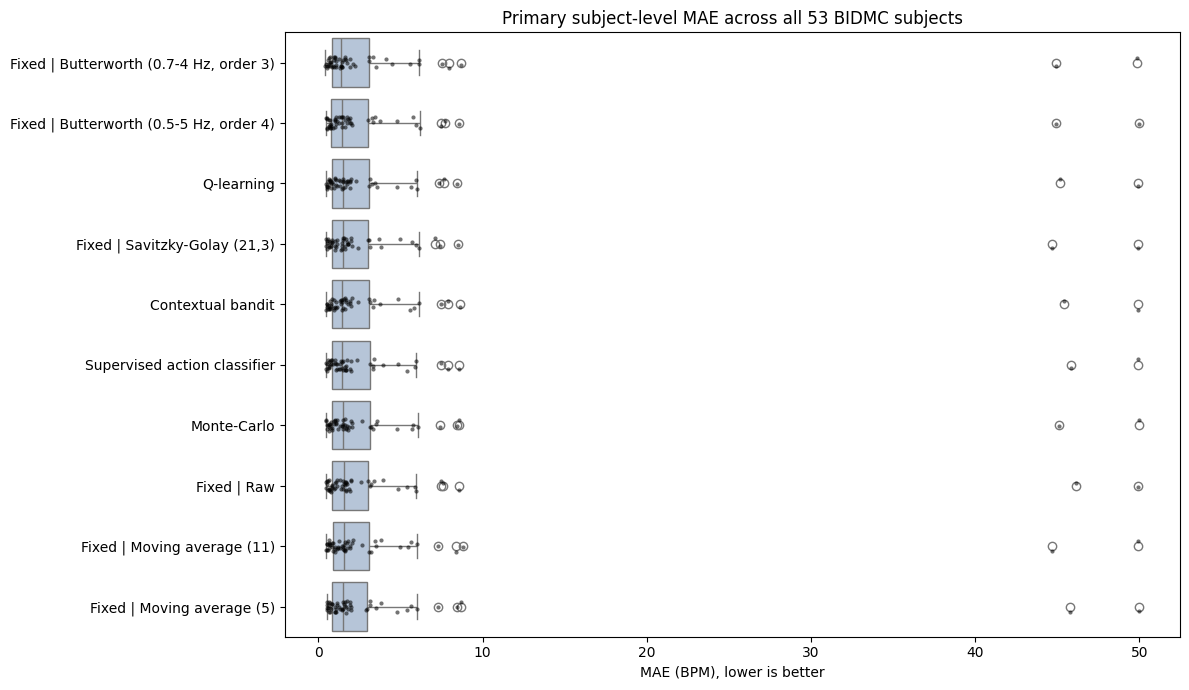

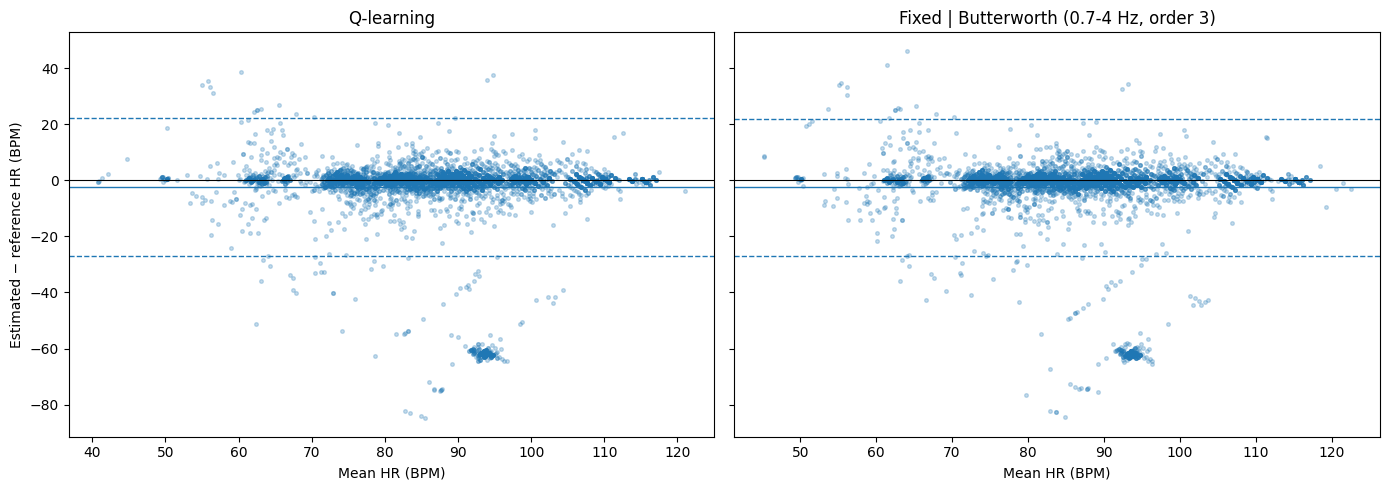

In [24]:
# Export reproducible paper tables, figures, and configuration.
from pathlib import Path
import json

P_OUTPUT_DIR = Path("paper_outputs")
P_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
P_EXPORT_TABLES = {
    "window_level_results": P_RESULTS,
    "fold_level_results": P_FOLD_RESULTS,
    "fold_level_significance_exploratory": P_FOLD_SIGNIFICANCE,
    "subject_level_results": P_SUBJECT_RESULTS,
    "subject_level_summary_bootstrap_ci": P_SUBJECT_SUMMARY,
    "subject_level_significance_primary": P_SUBJECT_SIGNIFICANCE,
    "window_level_bland_altman": P_BA_SUMMARY,
    "subject_level_bland_altman": P_SUBJECT_BA_SUMMARY,
    "ablation_results": P_ABLATION,
    "ablation_summary": P_ABLATION_SUMMARY,
    "epsilon_results": P_EPSILON,
    "epsilon_summary": P_EPSILON_SUMMARY,
    "subject_audit": P_SUBJECT_AUDIT,
}
for table_name, table in P_EXPORT_TABLES.items():
    table.to_csv(P_OUTPUT_DIR / (table_name + ".csv"), index=False)

P_CONFIG = {
    "dataset": "BIDMC 1.0.0",
    "subjects": 53,
    "sampling_frequency_hz": int(FS),
    "window_seconds": 8,
    "step_seconds": 4,
    "cross_validation": "5-fold GroupKFold by patient_id",
    "algorithms": ["Fixed", "Monte-Carlo", "SARSA", "Q-learning", "Contextual bandit", "Supervised action classifier"],
    "state_features": P_FEATURE_NAMES,
    "actions": {str(k): value for k, value in P_ACTION_SPECS.items()},
    "agent_seeds": [int(seed) for seed in P_TRAIN_SEEDS],
    "agent_epochs": int(P_AGENT_EPOCHS),
    "ablation_epochs": int(P_ABLATION_EPOCHS),
    "epsilon_grid": [float(value) for value in P_EPSILON_GRID],
    "primary_inference_unit": "patient",
    "bootstrap_resamples": 2000,
}
with open(P_OUTPUT_DIR / "experiment_config.json", "w") as handle:
    json.dump(P_CONFIG, handle, indent=2)

if "fig" in globals():
    fig.savefig(P_OUTPUT_DIR / "overview_300dpi.png", dpi=300, bbox_inches="tight")

subject_order = (
    P_SUBJECT_AGG.groupby("Method")["MAE (BPM)"].mean()
    .sort_values().index.tolist()
)
fig_subject, ax_subject = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=P_SUBJECT_AGG, x="MAE (BPM)", y="Method",
    order=subject_order, color="lightsteelblue", ax=ax_subject,
)
sns.stripplot(
    data=P_SUBJECT_AGG, x="MAE (BPM)", y="Method",
    order=subject_order, color="black", size=3, alpha=0.55, ax=ax_subject,
)
ax_subject.set_title("Primary subject-level MAE across all 53 BIDMC subjects")
ax_subject.set_xlabel("MAE (BPM), lower is better")
ax_subject.set_ylabel("")
fig_subject.tight_layout()
fig_subject.savefig(P_OUTPUT_DIR / "subject_level_mae_300dpi.png", dpi=300, bbox_inches="tight")

best_fixed_for_export = P_FOLD_RESULTS[
    P_FOLD_RESULTS.Method.str.startswith("Fixed |")
].groupby("Method")["MAE (BPM)"].mean().idxmin()
fig_ba, axes_ba = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, method, seed in zip(
    axes_ba, [P_REFERENCE_METHOD, best_fixed_for_export],
    [P_TRAIN_SEEDS[0], 0],
):
    keys = [key for key in P_PREDICTION_STORE if key[1] == method and key[2] == seed]
    combined = pd.concat([P_PREDICTION_STORE[key] for key in sorted(keys)], ignore_index=True)
    finite = np.isfinite(combined["prediction"].to_numpy())
    prediction = combined.loc[finite, "prediction"].to_numpy()
    reference = combined.loc[finite, "reference_hr"].to_numpy()
    mean_hr = (prediction + reference) / 2
    difference = prediction - reference
    axis.scatter(mean_hr, difference, s=7, alpha=0.25)
    bias = difference.mean()
    loa_sd = difference.std(ddof=1) if len(difference) > 1 else 0.0
    for value, style in [(bias, "-"), (bias + 1.96 * loa_sd, "--"), (bias - 1.96 * loa_sd, "--")]:
        axis.axhline(value, color="tab:blue", linestyle=style, linewidth=1)
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_title(method)
    axis.set_xlabel("Mean HR (BPM)")
axes_ba[0].set_ylabel("Estimated − reference HR (BPM)")
fig_ba.tight_layout()
fig_ba.savefig(P_OUTPUT_DIR / "bland_altman_q_vs_fixed_300dpi.png", dpi=300, bbox_inches="tight")

print("Exported", len(P_EXPORT_TABLES), "tables and paper figures to:", P_OUTPUT_DIR.resolve())
